In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pyJHTDB

plt.rcParams.update(plt.rcParamsDefault)
#plt.rcParams['text.usetex'] = True
plt.rcParams['font.size'] = 12
plt.rcParams['font.family'] = "serif"

import matplotlib as mpl
mpl.rcParams['agg.path.chunksize'] = 100000

In [2]:
dx = 0.001
shifts = np.array([0., 
                   0.001, 0.001 + 0.1 * dx, 
                   0.01, 0.01 + dx, 
                   0.05, 0.05 + dx,
                   0.1, 0.1 + dx,
                   0.126, 0.126 + dx,
                   0.158, 0.159 + dx,
                   0.2, 0.2 + dx,
                   0.251, 0.251 + dx,
                   0.316, 0.316 + dx,
                   0.398, 0.398 + dx,
                   0.5, 0.5 + dx,
                   0.631, 0.631 + dx,
                   0.794, 0.794 + dx,
                   1., 1. + dx,
                   2., 2. + dx])
num_shifts = len(shifts)

In [3]:
v1 = np.load('data-points.npy')
v2 = np.load('data-points2.npy')
v3 = np.load('data-points3.npy')
v4 = np.load('data-points4.npy')
v5 = np.load('data-points5.npy')

v = np.concatenate((v1, v2, v3, v4, v5))

num_points = len(v)

In [4]:
num_points

980000

In [8]:
v[980000-1]

array([-1.61757147, -1.61725605, -1.6172142 , -1.60641289, -1.6036762 ,
       -1.44767427, -1.44302535, -1.41337693, -1.41220367, -1.29051793,
       -1.28404546, -1.05587602, -1.0438211 , -0.8649959 , -0.86385536,
       -0.95836437, -0.95726264, -0.77310795, -0.76470309, -0.82017124,
       -0.81835198, -0.52618003, -0.52686405, -1.11207616, -1.10298908,
       -0.99478132, -0.9981606 , -1.07825279, -1.07595241, -0.20480056,
       -0.20100388])

In [19]:
v[1, 2]

1.4397008419036865

In [20]:
b = np.zeros(num_shifts)
for k in range(num_points):
    for i in range(len(b)):
        b[i] += v[k, 0] * v[k, i]
b /= num_points

In [21]:
b

array([0.4095126 , 0.40949678, 0.40949341, 0.40800132, 0.40770488,
       0.38978023, 0.3893056 , 0.36947211, 0.36912394, 0.36080712,
       0.3604908 , 0.35119068, 0.35062373, 0.33986045, 0.33960879,
       0.32754503, 0.32731251, 0.31282158, 0.31260127, 0.29579692,
       0.29560397, 0.27710442, 0.27692532, 0.25534099, 0.25518686,
       0.23118453, 0.23105197, 0.2060538 , 0.20594158, 0.14051553,
       0.14049446])

In [22]:
s = b[0] - b

In [23]:
s

array([0.00000000e+00, 1.58260412e-05, 1.91970569e-05, 1.51128303e-03,
       1.80772645e-03, 1.97323699e-02, 2.02070004e-02, 4.00404894e-02,
       4.03886631e-02, 4.87054796e-02, 4.90218060e-02, 5.83219225e-02,
       5.88888735e-02, 6.96521555e-02, 6.99038108e-02, 8.19675699e-02,
       8.22000907e-02, 9.66910190e-02, 9.69113345e-02, 1.13715687e-01,
       1.13908637e-01, 1.32408178e-01, 1.32587284e-01, 1.54171614e-01,
       1.54325746e-01, 1.78328075e-01, 1.78460635e-01, 2.03458798e-01,
       2.03571027e-01, 2.68997072e-01, 2.69018140e-01])

In [24]:
(np.log(s[2::2]) - np.log(s[1::2])) / (np.log(shifts[2::2]) - np.log(shifts[1::2]))

array([2.02601883, 1.87924284, 1.20027847, 0.87011701, 0.81891588,
       0.76908207, 0.72310548, 0.71242953, 0.72034059, 0.67559133,
       0.67655728, 0.63102289, 0.5903732 , 0.55172599, 0.15667777])

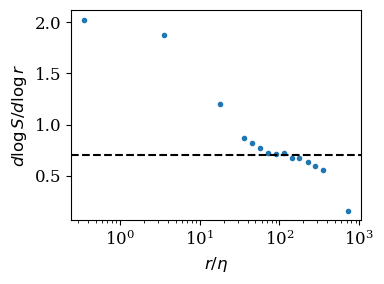

In [25]:
plt.figure(figsize=(4, 3))
plt.semilogx(shifts[1::2] / 0.0028, (np.log(s[2::2]) - np.log(s[1::2])) / (np.log(shifts[2::2]) - np.log(shifts[1::2])), '.')
plt.axhline(0.7, 0, 1, linestyle = '--', color = 'black')
plt.xlabel('$r/\eta$')
plt.ylabel('$d \log S / d \log r$')
plt.tight_layout()
#plt.savefig('ld.png')
#plt.savefig('ld.pdf')
plt.show()

In [26]:
shifts[2::2] - shifts[1::2]

array([0.0001, 0.001 , 0.001 , 0.001 , 0.001 , 0.002 , 0.001 , 0.001 ,
       0.001 , 0.001 , 0.001 , 0.001 , 0.001 , 0.001 , 0.001 ])

In [27]:
num_points

960000